In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
import spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)  # force reload after edits
from spk_feat_cluster_comp_analysis import (
    compile_experiment_results,
    plot_feature_distribution_grid,
    plot_cluster_waveform_grid,
    plot_cluster_legend,
)

CLUSTER_PKL_DIR = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/'

In [2]:
df_master = compile_experiment_results(CLUSTER_PKL_DIR)

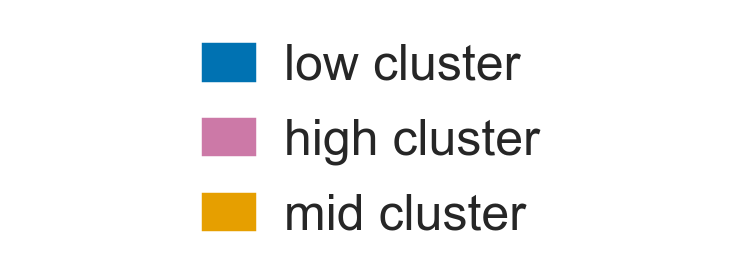

In [3]:
# Legend — same color scheme as main figure
plot_cluster_legend(fontsize=18)
plt.show()

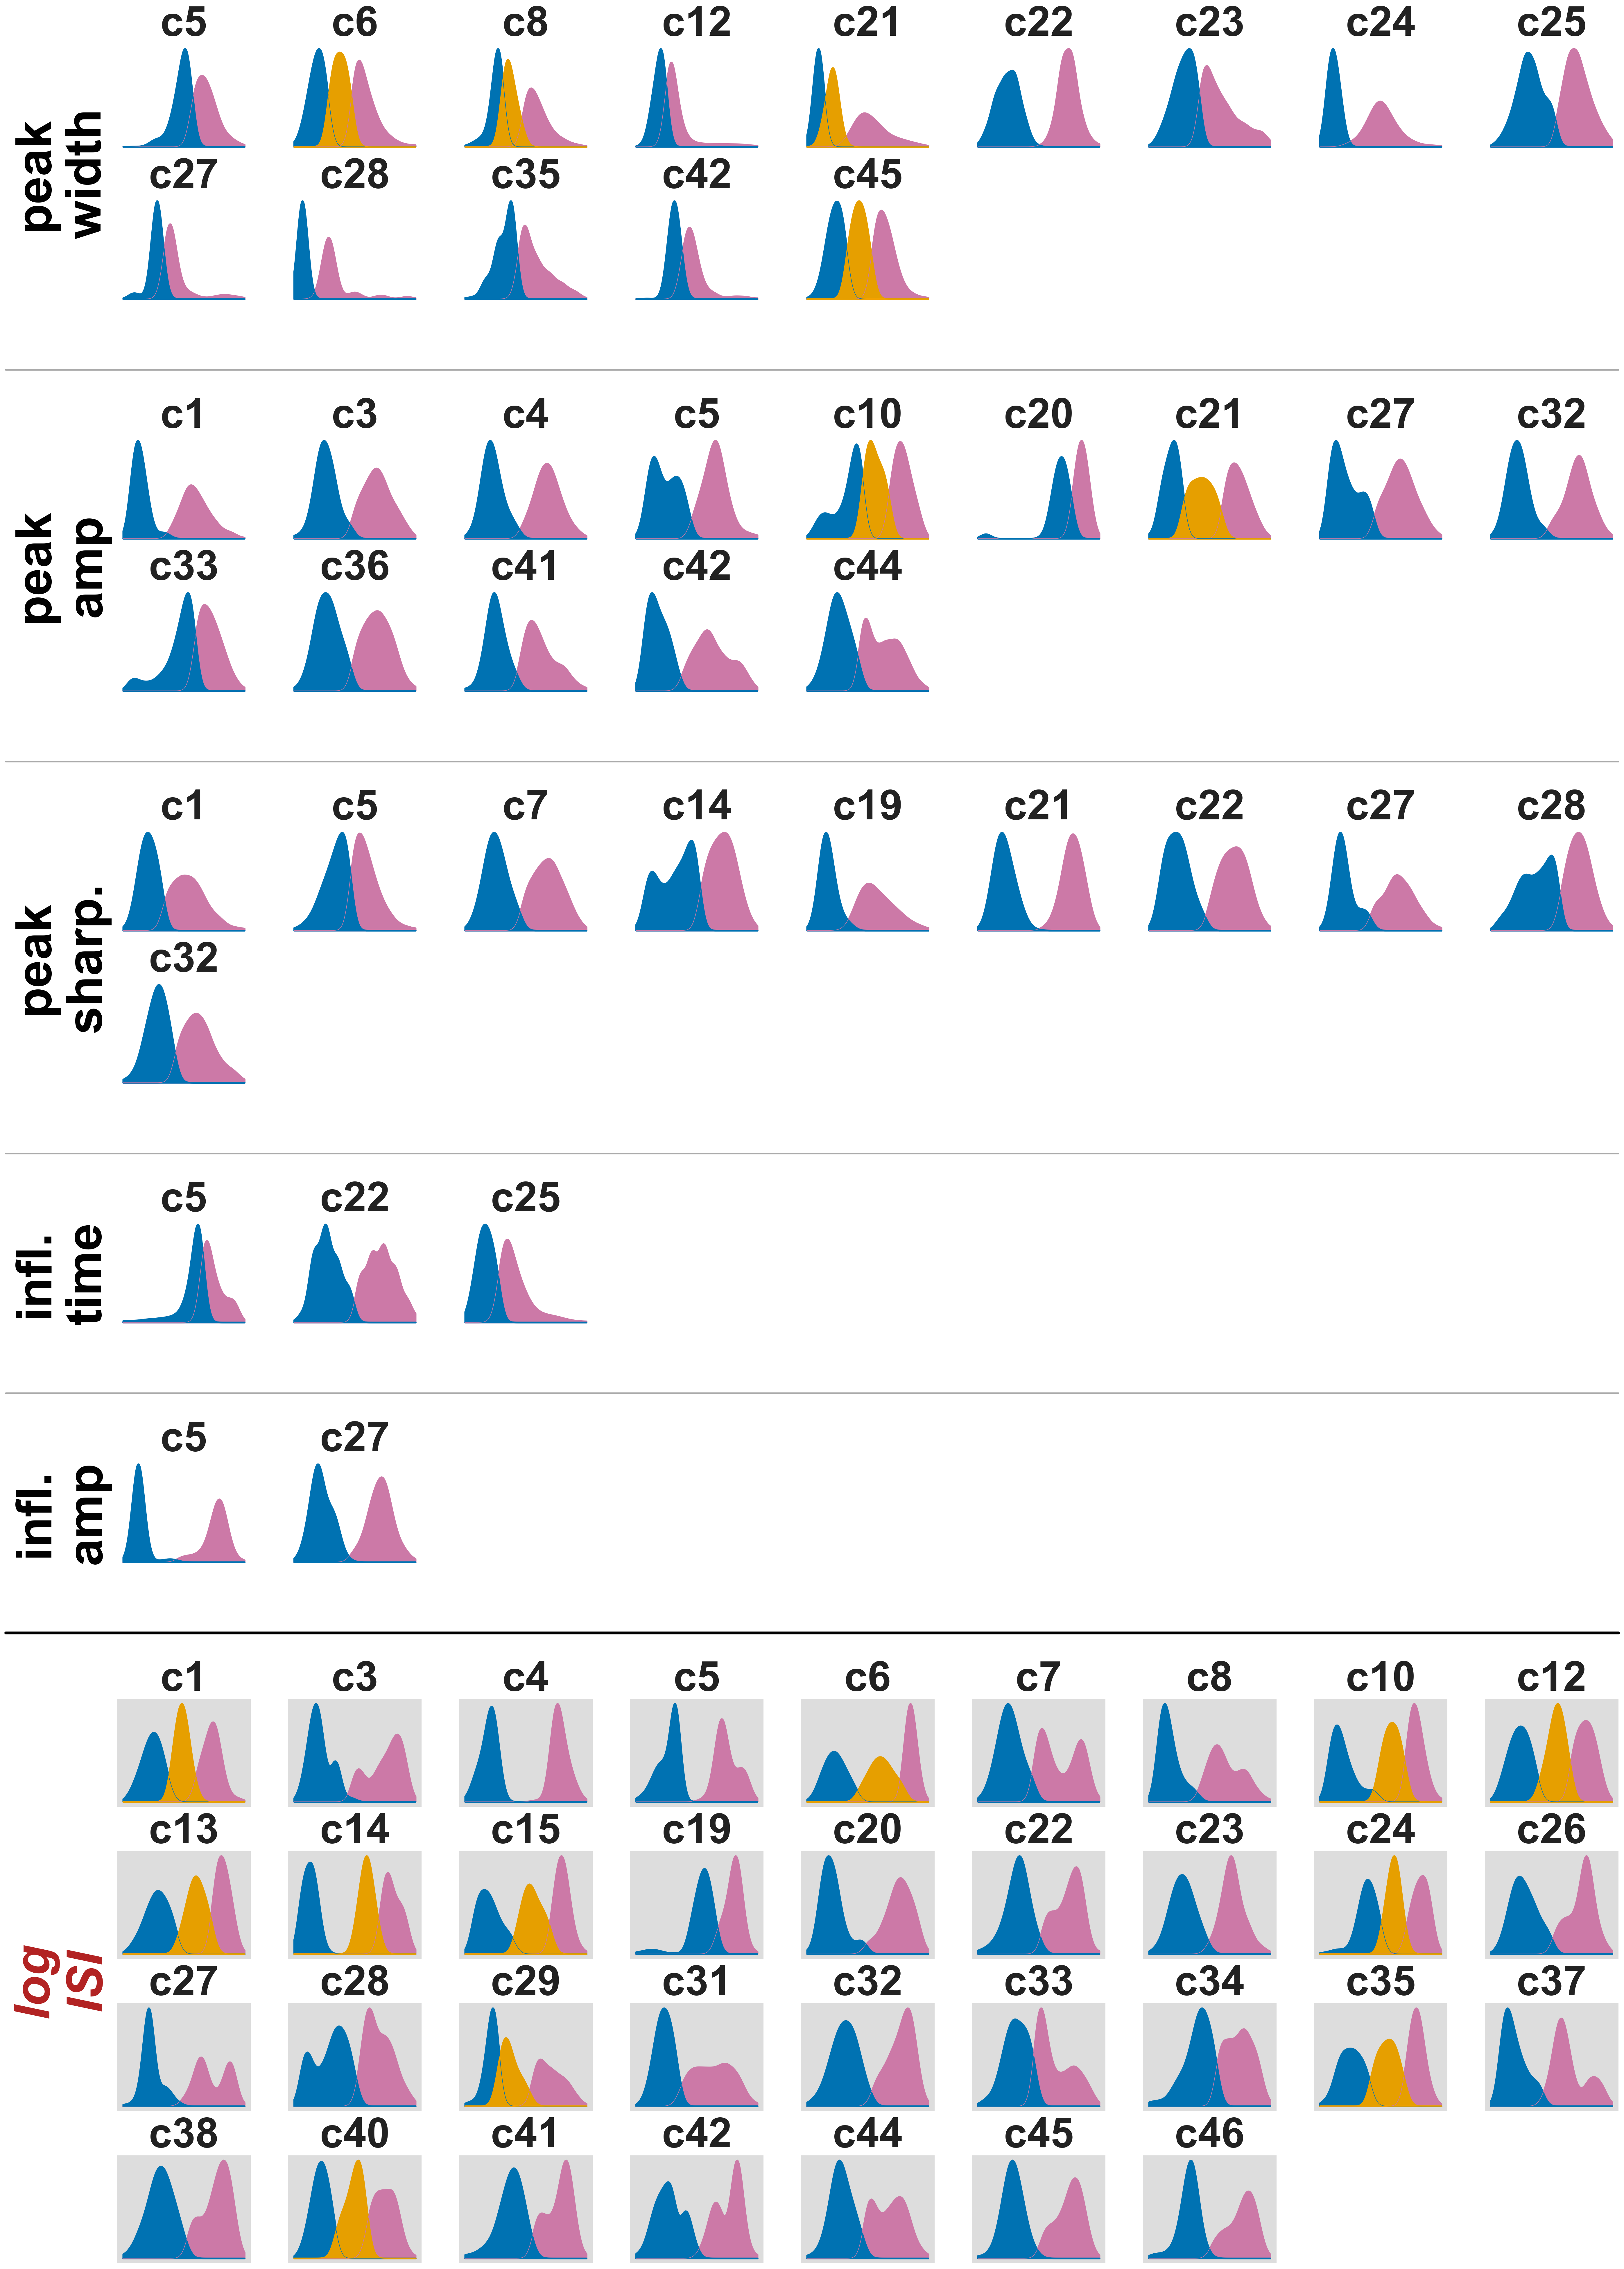

In [12]:
FEAT_LABELS = {
    'peak_width':      'peak\nwidth',
    'peak_amp':        'peak\namp',
    'exp_lambda':      'exp\nλ',
    'peak_sharpness':  'peak\nsharp.',
    'inflection_time': 'infl.\ntime',
    'inflection_amp':  'infl.\namp',
    'log_isi':         'log\nISI',
}

# exp_lambda: old cluster pickles have normalized 0-10 values → hidden.
# peak_width=0: degenerate fits → excluded via feature_min_vals.
# c15 peak_width and c7 inflection_time: clusters only 0.02ms apart —
#   any smoothing sufficient to remove quantization spikes merges them.
#   Excluded here and from supp plot 2 (waveform viz).
fig = plot_feature_distribution_grid(
    df_master,
    CLUSTER_PKL_DIR,
    n_cols_per_row=9,
    cell_w=3.5,
    cell_h=2.8,
    title_fontsize=52,
    ylabel_fontsize=62,
    hspace=0.5,
    clip_pct=2,
    min_bw_frac=0.05,
    feature_labels=FEAT_LABELS,
    feature_min_vals={'peak_width': 0.01},
    cells_to_plot={'exp_lambda': []},
    cells_to_exclude={
        'peak_width':      ['c15'],
        'inflection_time': ['c7'],
    },
)
plt.show()

In [ ]:
FEAT_LABELS_WF = {
    'peak_width':      'peak\nwidth',
    'peak_amp':        'peak\namp',
    'exp_lambda':      'exp\nλ',
    'peak_sharpness':  'peak\nsharp.',
    'inflection_time': 'infl.\ntime',
    'inflection_amp':  'infl.\namp',
}

fig = plot_cluster_waveform_grid(
    df_master,
    CLUSTER_PKL_DIR,
    n_cols_per_row=10,
    cell_w=3.5,
    cell_h=2.8,
    title_fontsize=52,
    ylabel_fontsize=62,
    hspace=0.5,
    half_win=200,
    max_rows=12,
    feature_labels=FEAT_LABELS_WF,
    cells_to_exclude={
        'peak_width':      ['c15'],
        'inflection_time': ['c7'],
    },
)
plt.show()

**Figure SX. Spike waveform feature distributions by cluster — all spe-1 cells.**

Each panel shows the within-cell distribution of a spike waveform feature across all spikes from one neuron, split by cluster assignment. Colors match Figure X: blue = low cluster, pink = high cluster, gold = mid cluster (when three clusters were detected). Rows group cells by the feature that clustered; only cells where ≥2 clusters were detected for that feature are shown. Features are ordered by clustering prevalence (fraction of cells with ≥2 clusters): peak width, peak amplitude, exponential decay rate (exp lambda), peak sharpness, inflection amplitude, inflection time. Log inter-spike interval (log ISI, grey background) is shown last as it is a firing-rate measure, not a waveform shape feature. Panels within each feature row are sorted by cell number.